# ODD + OOD Detection for Safe Autonomy
**Camera-based safety gate for autonomous driving**

- **Input**: Front camera frame
- **Output**: "Trust / Abstain" gate decision
- **ODD**: Daytime + Clear weather + Urban/Highway
- **OOD buckets**: Night, Rain, Fog/Snow

**Members**: Tharun Reddy Challabotla, HariChandana Srikurmum, Srija

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm
!pip install -q kagglehub

In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Dataset Download (BDD100K Weather Classification via kagglehub)

Uses `kagglehub` — no `kaggle.json` file upload needed.  
On first run it will ask you to authenticate via browser (one-time). The dataset is cached in `~/.cache/kagglehub` and reused on subsequent runs.

In [3]:
import kagglehub

# Download latest version — authenticates via browser on first run
# Credentials are cached in ~/.cache/kagglehub after the first login
kaggle_path = kagglehub.dataset_download('marquis03/bdd100k-weather-classification')
print('Path to dataset files:', kaggle_path)

from pathlib import Path
BDD_RAW = Path(kaggle_path)

# kagglehub sometimes nests files under a version subfolder;
# find the directory that actually contains train/ and val/ folders
def find_dataset_root(base: Path) -> Path:
    if (base / 'train').exists() or (base / 'val').exists():
        return base
    for child in sorted(base.rglob('train')):
        if child.is_dir():
            return child.parent
    return base
BDD_RAW = find_dataset_root(BDD_RAW)
print(f'Dataset root: {BDD_RAW}')

# Show splits and weather folders
for split in ['train', 'val']:
    split_dir = BDD_RAW / split
    if split_dir.exists():
        folders = [f.name for f in sorted(split_dir.iterdir()) if f.is_dir()]
        print(f'  {split}: {folders}')

100%|██████████| 5.27G/5.27G [02:14<00:00, 42.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/bdd100k-weather-classification/versions/1
Dataset root: /root/.cache/kagglehub/datasets/marquis03/bdd100k-weather-classification/versions/1
  train: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']
  val: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']


In [4]:
# Verify dataset structure
DATA_ROOT = BDD_RAW  # alias used throughout the notebook

total_imgs = sum(1 for p in BDD_RAW.rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png'})
print(f'Total images found: {total_imgs:,}')

Total images found: 99,863


In [5]:
# --- CELL 1: ODD/OOD DATASET SETUP (IMPROVED) ---

from torch.utils.data import WeightedRandomSampler

# Define a narrow ODD so the safety gate learns what "normal" looks like.
ID_WEATHERS = {'clear'}
OOD_WEATHERS = {'rainy', 'snowy', 'foggy'}
VAL_WEATHERS = ID_WEATHERS | OOD_WEATHERS

class BDDWeatherOODDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, include_weathers=None, train_id_only=False):
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.samples = []
        include_weathers = {w.lower() for w in include_weathers} if include_weathers else None

        for weather_folder in sorted(self.root_dir.iterdir()):
            if not weather_folder.is_dir():
                continue

            weather = weather_folder.name.lower()
            if include_weathers and weather not in include_weathers:
                continue

            if weather in ID_WEATHERS:
                cls_label = 0
                ood_label = 0
            elif weather in OOD_WEATHERS:
                cls_label = 1
                ood_label = 1
            else:
                continue

            if train_id_only and ood_label == 1:
                continue

            for img_path in weather_folder.glob('*.jpg'):
                self.samples.append((str(img_path), cls_label, ood_label, weather))

        print(
            f"Loaded {split}: {len(self.samples)} samples "
            f"| train_id_only={train_id_only}"
        )
        print('Weather counts:', Counter([weather for _, _, _, weather in self.samples]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls_label, ood_label, weather = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, cls_label, ood_label, weather

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Train only on ODD data; validate on both ID and OOD.
train_dataset = BDDWeatherOODDataset(
    DATA_ROOT,
    split='train',
    transform=train_transform,
    include_weathers=ID_WEATHERS,
    train_id_only=True,
)

val_dataset = BDDWeatherOODDataset(
    DATA_ROOT,
    split='val',
    transform=eval_transform,
    include_weathers=VAL_WEATHERS,
    train_id_only=False,
)

extract_train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=2)
extract_val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)



Loaded train: 37344 samples | train_id_only=True
Weather counts: Counter({'clear': 37344})
Loaded val: 6866 samples | train_id_only=False
Weather counts: Counter({'clear': 5346, 'snowy': 769, 'rainy': 738, 'foggy': 13})


In [6]:
# --- CELL 2: EXTRACT AND CACHE BACKBONE FEATURES ---

backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
backbone.fc = nn.Identity()
backbone = backbone.to(DEVICE)
backbone.eval()


def extract_and_save_features(loader, save_prefix):
    features_list = []
    cls_labels_list = []
    ood_labels_list = []

    print(f"Extracting features for {save_prefix}...")
    with torch.no_grad():
        for images, cls_labels, ood_labels, _ in tqdm(loader, desc=f"Processing {save_prefix}"):
            images = images.to(DEVICE)
            feats = backbone(images)
            features_list.append(feats.cpu())
            cls_labels_list.append(cls_labels.cpu())
            ood_labels_list.append(ood_labels.cpu())

    all_features = torch.cat(features_list, dim=0)
    all_cls_labels = torch.cat(cls_labels_list, dim=0)
    all_ood_labels = torch.cat(ood_labels_list, dim=0)

    torch.save(all_features, f"{save_prefix}_features.pt")
    torch.save(all_cls_labels, f"{save_prefix}_cls_labels.pt")
    torch.save(all_ood_labels, f"{save_prefix}_ood_labels.pt")
    print(
        f"Saved {save_prefix}: features={all_features.shape}, "
        f"cls_labels={all_cls_labels.shape}, ood_labels={all_ood_labels.shape}"
    )

# Run once, then keep the cached .pt files.
extract_and_save_features(extract_train_loader, 'train')
extract_and_save_features(extract_val_loader, 'val')



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Extracting features for train...


Processing train:   0%|          | 0/292 [00:00<?, ?it/s]

Saved train: features=torch.Size([37344, 2048]), cls_labels=torch.Size([37344]), ood_labels=torch.Size([37344])
Extracting features for val...


Processing val:   0%|          | 0/54 [00:00<?, ?it/s]

Saved val: features=torch.Size([6866, 2048]), cls_labels=torch.Size([6866]), ood_labels=torch.Size([6866])


In [7]:
# --- CELL 3: LOAD CACHED FEATURES ---

from torch.utils.data import TensorDataset

train_features = torch.load('train_features.pt')
train_cls_labels = torch.load('train_cls_labels.pt')
train_ood_labels = torch.load('train_ood_labels.pt')

val_features = torch.load('val_features.pt')
val_cls_labels = torch.load('val_cls_labels.pt')
val_ood_labels = torch.load('val_ood_labels.pt')

print('Train feature shape:', train_features.shape)
print('Val feature shape  :', val_features.shape)
print('Train OOD label counts:', Counter(train_ood_labels.tolist()))
print('Val OOD label counts  :', Counter(val_ood_labels.tolist()))



Train feature shape: torch.Size([37344, 2048])
Val feature shape  : torch.Size([6866, 2048])
Train OOD label counts: Counter({0: 37344})
Val OOD label counts  : Counter({0: 5346, 1: 1520})


In [8]:
# --- CELL 4: FEATURE-SPACE OOD DETECTOR SETUP ---

train_id_mask = (train_ood_labels == 0)
id_train_features = train_features[train_id_mask].float()

print('ID-only training feature shape:', id_train_features.shape)

# Estimate the ID feature distribution using the frozen ResNet embeddings.
feature_mean = id_train_features.mean(dim=0)

# Add shrinkage for numerical stability before inverting the covariance matrix.
feature_cov = torch.cov(id_train_features.T) + 1e-3 * torch.eye(id_train_features.shape[1])
feature_precision = torch.linalg.pinv(feature_cov)


def mahalanobis_score(features, mean, precision):
    centered = features.float() - mean.unsqueeze(0)
    projected = torch.matmul(centered, precision)
    distances = torch.sum(projected * centered, dim=1)
    return distances


# Optional lightweight baseline: plain Euclidean distance to the ID centroid.
def centroid_distance_score(features, mean):
    centered = features.float() - mean.unsqueeze(0)
    return torch.norm(centered, dim=1)


print('Feature-distribution statistics ready.')



ID-only training feature shape: torch.Size([37344, 2048])
Feature-distribution statistics ready.


In [9]:
# --- CELL 5: SCORE THE VALIDATION SET ---

val_ood_arr = val_ood_labels.numpy()
val_cls_arr = val_cls_labels.numpy()

val_mahal = mahalanobis_score(val_features, feature_mean, feature_precision).cpu().numpy()
val_centroid = centroid_distance_score(val_features, feature_mean).cpu().numpy()

print('Scored validation features with Mahalanobis and centroid-distance baselines.')



Scored validation features with Mahalanobis and centroid-distance baselines.


Mahalanobis Distance   | AUROC=0.6525 | AUPR=0.3391 | FPR@95TPR=0.8315
Centroid Distance      | AUROC=0.6024 | AUPR=0.2760 | FPR@95TPR=0.8801

Tuned Mahalanobis threshold:
{'threshold': 415.40216193271044, 'false_safe_rate': 0.05, 'coverage': 0.13807165744247013}


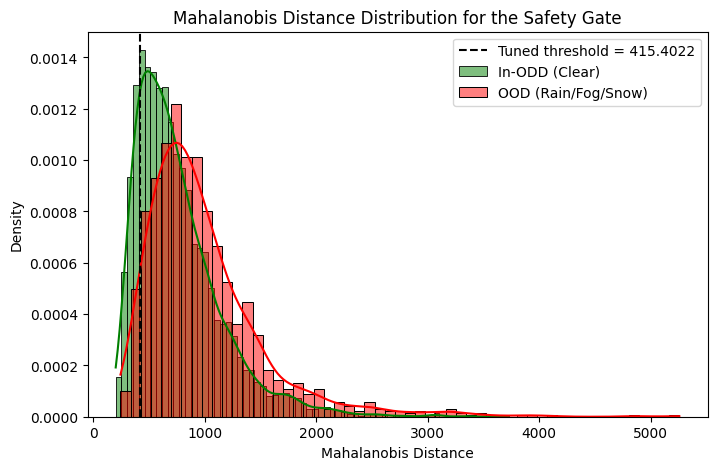

In [10]:
# --- CELL 6: OOD METRICS AND THRESHOLD TUNING ---

def fpr_at_95_tpr(y_true, score):
    fpr, tpr, _ = roc_curve(y_true, score)
    valid = np.where(tpr >= 0.95)[0]
    return float(fpr[valid[0]]) if len(valid) else 1.0


def summarize_ood_metrics(ood_labels, score_map):
    results = {}
    for name, score in score_map.items():
        results[name] = {
            'AUROC': roc_auc_score(ood_labels, score),
            'AUPR': average_precision_score(ood_labels, score),
            'FPR@95TPR': fpr_at_95_tpr(ood_labels, score),
        }
    return results


def tune_threshold(ood_labels, ood_score, false_safe_budget=0.05):
    thresholds = np.quantile(ood_score, np.linspace(0.01, 0.99, 200))
    best = None

    for threshold in thresholds:
        trust_mask = ood_score < threshold
        false_safe_rate = float(np.mean(trust_mask[ood_labels == 1])) if np.any(ood_labels == 1) else 0.0
        coverage = float(np.mean(trust_mask))

        if false_safe_rate <= false_safe_budget:
            if best is None or coverage > best['coverage']:
                best = {
                    'threshold': float(threshold),
                    'false_safe_rate': false_safe_rate,
                    'coverage': coverage,
                }

    if best is None:
        best = {
            'threshold': float(np.max(ood_score)),
            'false_safe_rate': 0.0,
            'coverage': 0.0,
        }

    return best


score_map = {
    'Mahalanobis Distance': val_mahal,
    'Centroid Distance': val_centroid,
}

metric_summary = summarize_ood_metrics(val_ood_arr, score_map)
for metric_name, metric_values in metric_summary.items():
    print(
        f"{metric_name:22s} | "
        f"AUROC={metric_values['AUROC']:.4f} | "
        f"AUPR={metric_values['AUPR']:.4f} | "
        f"FPR@95TPR={metric_values['FPR@95TPR']:.4f}"
    )

best_gate = tune_threshold(val_ood_arr, val_mahal, false_safe_budget=0.05)
MAHAL_THRESHOLD = best_gate['threshold']
print('\nTuned Mahalanobis threshold:')
print(best_gate)

plt.figure(figsize=(8, 5))
sns.histplot(val_mahal[val_ood_arr == 0], color='green', label='In-ODD (Clear)', kde=True, stat='density')
sns.histplot(val_mahal[val_ood_arr == 1], color='red', label='OOD (Rain/Fog/Snow)', kde=True, stat='density')
plt.axvline(MAHAL_THRESHOLD, color='black', linestyle='--', label=f'Tuned threshold = {MAHAL_THRESHOLD:.4f}')
plt.title('Mahalanobis Distance Distribution for the Safety Gate')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Density')
plt.legend()
plt.show()



In [11]:
# --- CELL 7: DEPLOYMENT-STYLE SAFETY GATE ---

def runtime_safety_gate(feature_batch, threshold):
    scores = mahalanobis_score(feature_batch, feature_mean, feature_precision).cpu().numpy()
    decisions = []

    for score in scores:
        decision = 'ABSTAIN' if score >= threshold else 'TRUST'
        decisions.append({
            'decision': decision,
            'mahalanobis_score': float(score),
        })

    return decisions


print('Deploying Mahalanobis safety gate...\n')
print('=' * 80)

sample_features = val_features[:10]
sample_ood_labels = val_ood_labels[:10].numpy()
gate_results = runtime_safety_gate(sample_features, MAHAL_THRESHOLD)

for i, result in enumerate(gate_results, start=1):
    actual = 'In-ODD' if sample_ood_labels[i - 1] == 0 else 'OOD'
    print(f"Frame {i} [Ground Truth: {actual}]")
    print(f"  -> Decision            : {result['decision']}")
    print(f"  -> Mahalanobis Score   : {result['mahalanobis_score']:.4f}")
    print('-' * 80)



Deploying Mahalanobis safety gate...

Frame 1 [Ground Truth: In-ODD]
  -> Decision            : TRUST
  -> Mahalanobis Score   : 217.3847
--------------------------------------------------------------------------------
Frame 2 [Ground Truth: In-ODD]
  -> Decision            : ABSTAIN
  -> Mahalanobis Score   : 1165.1112
--------------------------------------------------------------------------------
Frame 3 [Ground Truth: In-ODD]
  -> Decision            : ABSTAIN
  -> Mahalanobis Score   : 695.7877
--------------------------------------------------------------------------------
Frame 4 [Ground Truth: In-ODD]
  -> Decision            : ABSTAIN
  -> Mahalanobis Score   : 953.3903
--------------------------------------------------------------------------------
Frame 5 [Ground Truth: In-ODD]
  -> Decision            : ABSTAIN
  -> Mahalanobis Score   : 559.3095
--------------------------------------------------------------------------------
Frame 6 [Ground Truth: In-ODD]
  -> Decision    